# Data Wrangling, Feature Engineering, dan EDA
# Acne Severity Classification Dataset

Notebook ini digunakan untuk mengolah keseluruhan dataset gambar jerawat mulai dari import data, wrangling, feature engineering, EDA, quality checking, hingga export metadata akhir.

Dataset memiliki struktur:
- Folder **JPEGImages** berisi seluruh gambar.
- File **TXT** berisi daftar nama gambar berdasarkan level jerawat.

Tahapan yang dilakukan:
1. Import dataset lokal di VSCode.
2. Data Understanding
3. Gathering data dari file TXT.
4. Assessing data.
5. Cleaning data.
6. Feature engineering.
7. Exploratory Data Analysis.
8. Quality checking.
9. Export metadata akhir.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# 2. Data Understanding


**2.1 Menentukan Lokasi Dataset**

Pada tahap ini, path dataset ditentukan terlebih dahulu. Folder Classification berisi file TXT sebagai sumber label dan folder JPEGImages sebagai tempat semua gambar disimpan.

In [7]:
data_path = "../data/Acnedataset"
image_dir = "../data/Acnedataset/JPEGImages"

txt_files = [
    "NNEW_trainval_0.txt",
    "NNEW_trainval_1.txt",
    "NNEW_trainval_2.txt",
    "NNEW_trainval_3.txt",
    "NNEW_trainval_4.txt",
    "NNEW_test_0.txt",
    "NNEW_test_1.txt",
    "NNEW_test_2.txt",
    "NNEW_test_3.txt",
    "NNEW_test_4.txt"
]

In [8]:
print("Isi folder Classification:")
print(os.listdir(data_path))

print("\nJumlah gambar di folder JPEGImages:")
print(len(os.listdir(image_dir)))

Isi folder Classification:
['JPEGImages', 'NNEW_test_0.txt', 'NNEW_test_1.txt', 'NNEW_test_2.txt', 'NNEW_test_3.txt', 'NNEW_test_4.txt', 'NNEW_trainval_0.txt', 'NNEW_trainval_1.txt', 'NNEW_trainval_2.txt', 'NNEW_trainval_3.txt', 'NNEW_trainval_4.txt']

Jumlah gambar di folder JPEGImages:
1457


# 3. Gathering Data

Pada tahap ini, file TXT dibaca untuk mengambil daftar gambar berdasarkan level jerawat.

Dataset ini tidak menggunakan folder kelas secara langsung. Label kelas disimpan pada file TXT, sehingga kita perlu membaca file TXT dan mengubahnya menjadi dataframe.


**3.1 Membaca File TXT dan Membuat Dataframe**

Dataset ini tidak menggunakan folder kelas secara langsung. Label tingkat keparahan jerawat disimpan pada file TXT.

Pada tahap ini akan dilakukan:
- membaca file TXT,
- mengambil nama gambar,
- membuat filepath,
- memberi label level,
- menentukan split data.


In [9]:
import os
import re
import pandas as pd

data = []

for level in range(4):
    for split in ["trainval", "test"]:

        txt_path = os.path.join(data_path, f"NNEW_{split}_{level}.txt")

        if os.path.exists(txt_path):
            with open(txt_path, "r") as file:
                daftar = file.read().splitlines()

            for baris in daftar:
                bagian = baris.split()
                nama_gambar = bagian[0]

                # ambil level dari nama file, contoh: levle0_451.jpg
                match = re.search(r"levle(/d+)_", nama_gambar)
                label = int(match.group(1)) if match else level

                data.append({
                    "filename": nama_gambar,
                    "filepath": os.path.join(image_dir, nama_gambar).replace("\\", "/"),
                    "level": label,
                    "split": split
                })

df = pd.DataFrame(data)

print(df.head())

         filename                                       filepath  level  \
0    levle0_0.jpg    ../data/Acnedataset/JPEGImages/levle0_0.jpg      0   
1    levle0_1.jpg    ../data/Acnedataset/JPEGImages/levle0_1.jpg      0   
2  levle0_100.jpg  ../data/Acnedataset/JPEGImages/levle0_100.jpg      0   
3  levle0_101.jpg  ../data/Acnedataset/JPEGImages/levle0_101.jpg      0   
4  levle0_102.jpg  ../data/Acnedataset/JPEGImages/levle0_102.jpg      0   

      split  
0  trainval  
1  trainval  
2  trainval  
3  trainval  
4  trainval  


📌 **Insight**

Data dari seluruh file TXT berhasil dikumpulkan menjadi dataframe.

Kolom yang terbentuk:
- **filename**: nama file gambar.
- **filepath**: lokasi lengkap gambar.
- **level**: tingkat keparahan jerawat.
- **split**: pembagian trainval atau test.

**3.2 Mengecek Jumlah Data yang Berhasil Dikumpulkan**

Pada tahap ini, jumlah data dicek untuk memastikan semua file TXT sudah berhasil dibaca dan digabungkan ke dalam dataframe.

In [10]:
print("Jumlah total data:", len(df))
print("Jumlah kolom:", df.shape[1])

df.info()

Jumlah total data: 5828
Jumlah kolom: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5828 entries, 0 to 5827
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  5828 non-null   object
 1   filepath  5828 non-null   object
 2   level     5828 non-null   int64 
 3   split     5828 non-null   object
dtypes: int64(1), object(3)
memory usage: 182.2+ KB


# 4. Assessing Data

Tahap mengecek kondisi awal data. Di sini kamu mencari masalah seperti data kosong, duplikat, file gambar tidak ditemukan, label tidak sesuai, atau struktur data belum rapi.

**4.1 Cek Missing Value**

Missing value dicek untuk mengetahui apakah ada data kosong pada kolom penting seperti filename, filepath, level, dan split.

In [11]:
df.isnull().sum()

filename    0
filepath    0
level       0
split       0
dtype: int64

📌 **Insight**

Tidak ada data kosong pada metadata awal

**4.2 Cek Data Duplikat**

Data duplikat perlu dicek agar satu gambar tidak dihitung lebih dari satu kali.


In [ ]:
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)
print("Level:", sorted(df["level"].unique()))

df[df.duplicated()].head()

Jumlah data duplikat: 0
Jumlah baris data: 5828
Jumlah gambar unik: 1457
Level: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,filename,filepath,level,split


📌 **Insight**

Tidak ada baris data duplikat yang terdeteksi

**4.3 Cek File gambar yang tidak dapat ditemukan**

Tahap ini digunakan untuk memastikan semua gambar yang tertulis pada file TXT benar benar tersedia di Folder Images

In [13]:
df["file_exists"] = df["filepath"].apply(os.path.exists)

print("Jumlah gambar tersedia:", df["file_exists"].sum())
print("Jumlah gambar tidak ditemukan:", (~df["file_exists"]).sum())

df[df["file_exists"] == False].head()

Jumlah gambar tersedia: 5828
Jumlah gambar tidak ditemukan: 0


,filename,filepath,level,split,file_exists


**4.4 Cek Distribusi Level Awal**

Dataset asli memiliki level 0 - 4. Distribusi level awal dilakukan pengecekan untuk mengetahui jumlah gambar pada setiap level sebelum disesuaikan

In [ ]:
df["level"].value_counts().sort_index()

level
0    1457
1    1457
2    1457
3    1457
Name: count, dtype: int64

In [15]:
print("Total data:", len(df))

print("\nDistribusi level:")
print(df["level"].value_counts().sort_index())

print("\nDistribusi split:")
print(df["split"].value_counts())

print("\nCek data per split dan level:")
print(pd.crosstab(df["split"], df["level"]))

Total data: 5828

Distribusi level:
level
0    1457
1    1457
2    1457
3    1457
Name: count, dtype: int64

Distribusi split:
split
trainval    4660
test        1168
Name: count, dtype: int64

Cek data per split dan level:
level        0     1     2     3
split                           
test       292   292   292   292
trainval  1165  1165  1165  1165


# 5. Cleaning Data

Bertujuan unutk membersihkan masalah yang ditemukan saat Assesing.

**5.1 Menghapus data duplikat**

dilakukan pembersihan data duplikat agar satu gambar tidak terhitung lebih dari satu kali.

In [16]:
jumlah_awal = len(df)

df = (
    df
    .drop_duplicates(
        subset=[
            "filename",
            "split",
            "level"
        ]
    )
    .reset_index(drop=True)
)

jumlah_akhir = len(df)

print("Data sebelum:", jumlah_awal)
print("Data sesudah:", jumlah_akhir)

print("Data terhapus:", jumlah_awal-jumlah_akhir)

Data sebelum: 5828
Data sesudah: 5828
Data terhapus: 0


📌 **Insight**

Tidak ditemukan data yang terhapus karena di tahap assesing sendiri tidak ditemukan data duplikat, sehingga data sudah bersih dari data duplikat.

**5.4 Cek Gambar Corrupt**

Tahap ini memastikan apakah ada beberapa gambar yang tidak bisa dibuka

In [17]:
from PIL import Image

def check_corrupt(filepath):
    try:
        img = Image.open(filepath)
        img.verify()
        return False

    except:
        return True


df["is_corrupt"] = (
    df["filepath"]
    .apply(check_corrupt)
)

print(
    "Jumlah gambar corrupt:",
    df["is_corrupt"].sum()
)

Jumlah gambar corrupt: 0


# 6. Feature Engineering

Tahap membuat fitur baru dari gambar. Di sini kita tidak mengubah isi gambar, tetapi mengambil informasi penting dari gambar, seperti ukuran, resolusi, brightness, dan blur score.

**6.1 Import Library Tambahan**

In [18]:
from PIL import Image
import cv2
import numpy as np
import os

**6.2 Membuat fungsi ekstraksi fitur gambar**

Fungsi ini digunakan untuk membaca setiap gambar dan mengambil fitur penting. Fitur yang diambil adalah ukuran gambar, channel warna, ukuran file, aspect ratio, total pixels, brightness, dan blur score.

Brightness dihitung dari rata-rata nilai pixel grayscale. Blur score dihitung menggunakan variance of Laplacian. Semakin kecil nilai blur score, semakin besar kemungkinan gambar tersebut blur.

In [19]:
def extract_image_features(filepath):
    try:
        # Membaca gambar menggunakan PIL
        image = Image.open(filepath).convert("RGB")

        # Mengambil ukuran gambar
        width, height = image.size

        # Mengambil jumlah channel warna
        channel = len(image.getbands())

        # Mengambil ukuran file dalam KB
        file_size_kb = os.path.getsize(filepath) / 1024

        # Menghitung aspect ratio
        aspect_ratio = width / height

        # Menghitung total pixels
        total_pixels = width * height

        # Membaca gambar menggunakan OpenCV
        image_cv = cv2.imread(filepath)

        # Mengubah gambar menjadi grayscale
        gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

        # Menghitung brightness
        brightness = np.mean(gray)

        # Menghitung blur score
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

        return pd.Series({
            "width": width,
            "height": height,
            "channel": channel,
            "file_size_kb": round(file_size_kb, 2),
            "aspect_ratio": round(aspect_ratio, 4),
            "total_pixels": total_pixels,
            "brightness": round(brightness, 2),
            "blur_score": round(blur_score, 2)
        })

    except Exception as e:
        return pd.Series({
            "width": np.nan,
            "height": np.nan,
            "channel": np.nan,
            "file_size_kb": np.nan,
            "aspect_ratio": np.nan,
            "total_pixels": np.nan,
            "brightness": np.nan,
            "blur_score": np.nan
        })

**6.3 Menerapkan Fungsi ke keseluruhan dataset**

Fungsi ekstraksi fitur diterapkan ke semua gambar yang ada pada dataframe.

In [20]:
image_features = df["filepath"].apply(extract_image_features)

image_features.head()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


**6.4 Menggabungkan Fitur dengan dataframe utama**

Setelah fitur gambar berhasil dibuat, hasilnya digabungkan dengan dataframe utama agar semua informasi berada dalam satu tabel.


In [21]:
df = pd.concat([df, image_features], axis=1)

df.head()

,filename,filepath,level,split,file_exists,is_corrupt,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,levle0_0.jpg,../data/Acnedataset/JPEGImages/levle0_0.jpg,0,trainval,True,False,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,levle0_1.jpg,../data/Acnedataset/JPEGImages/levle0_1.jpg,0,trainval,True,False,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,levle0_100.jpg,../data/Acnedataset/JPEGImages/levle0_100.jpg,0,trainval,True,False,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,levle0_101.jpg,../data/Acnedataset/JPEGImages/levle0_101.jpg,0,trainval,True,False,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,levle0_102.jpg,../data/Acnedataset/JPEGImages/levle0_102.jpg,0,trainval,True,False,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


fitur hasil feature engineering sudah berhasil digabungkan ke dataframe utama. Dataset sekarang memiliki kolom tambahan seperti width, height, brightness, dan blur_score.

**6.5 Cek Hasil feature engineering**

Tahap ini digunakan untuk memastikan semua fitur baru berhasil dibuat dan tidak ada nilai kosong yang muncul setelah ekstraksi fitur.

In [22]:
feature_columns = [
    "width",
    "height",
    "channel",
    "file_size_kb",
    "aspect_ratio",
    "total_pixels",
    "brightness",
    "blur_score"
]

df[feature_columns].head()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97


**6.6 Cek Missing Value Pada fitur baru**

Missing value pada fitur baru dicek untuk memastikan tidak ada gambar yang gagal diproses saat feature engineering.

In [23]:
df[feature_columns].isnull().sum()

width           0
height          0
channel         0
file_size_kb    0
aspect_ratio    0
total_pixels    0
brightness      0
blur_score      0
dtype: int64

**6.7 Statistik Desk fitur Gambar**

Statistik deskriptif digunakan untuk melihat gambaran umum fitur gambar, seperti nilai minimum, maksimum, rata-rata, dan standar deviasi.

In [24]:
df[feature_columns].describe()

,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
count,5828.000000,5828.000000,5828.0,5828.000000,5828.000000,5.828000e+03,5828.000000,5828.000000
mean,2918.286205,3027.748799,3.0,756.628085,0.966242,9.782844e+06,97.547001,109.039472
std,1112.585773,1002.478625,0.0,328.363424,0.212263,4.178080e+06,17.995419,206.416327
min,143.000000,155.000000,3.0,3.250000,0.562300,2.431000e+04,42.910000,3.940000
25%,3112.000000,3456.000000,3.0,679.990000,0.900500,1.075507e+07,86.710000,38.350000
50%,3112.000000,3456.000000,3.0,855.490000,0.900500,1.075507e+07,95.560000,74.950000
75%,3112.000000,3456.000000,3.0,962.800000,0.900500,1.075507e+07,104.850000,113.740000
max,5184.000000,3456.000000,3.0,1353.240000,1.778400,1.791590e+07,174.880000,3963.120000


**6.8 Cek Sampel data setelah proses Feature Engineering**

Tahap ini digunakan untuk melihat beberapa baris data setelah fitur gambar ditambahkan.

In [25]:
df[
    [
        "filename",
        "split",
        "level",
        "width",
        "height",
        "channel",
        "file_size_kb",
        "aspect_ratio",
        "total_pixels",
        "brightness",
        "blur_score"
    ]
].head(10)

,filename,split,level,width,height,channel,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
0,levle0_0.jpg,trainval,0,525.0,700.0,3.0,48.00,0.7500,367500.0,107.39,439.83
1,levle0_1.jpg,trainval,0,3112.0,3456.0,3.0,827.53,0.9005,10755072.0,85.28,81.62
2,levle0_100.jpg,trainval,0,3112.0,3456.0,3.0,642.27,0.9005,10755072.0,81.70,40.81
3,levle0_101.jpg,trainval,0,3112.0,3456.0,3.0,881.05,0.9005,10755072.0,94.72,78.00
4,levle0_102.jpg,trainval,0,3112.0,3456.0,3.0,656.16,0.9005,10755072.0,81.50,27.97
5,levle0_104.jpg,trainval,0,3112.0,3456.0,3.0,979.73,0.9005,10755072.0,110.01,78.93
6,levle0_105.jpg,trainval,0,3112.0,3456.0,3.0,597.12,0.9005,10755072.0,73.49,22.87
7,levle0_106.jpg,trainval,0,3112.0,3456.0,3.0,828.40,0.9005,10755072.0,79.12,99.71
8,levle0_108.jpg,trainval,0,3112.0,3456.0,3.0,834.27,0.9005,10755072.0,101.83,70.64
9,levle0_109.jpg,trainval,0,3112.0,3456.0,3.0,805.69,0.9005,10755072.0,100.89,47.94


# 7. Exploratory Data Analysis

tTahap “mengenali kondisi dataset” sebelum lanjut ke modeling, supaya kita tahu data bersih, seimbang, dan layak digunakan atau masih ada masalah.

**7.1 Distribusi kelas**

Tahap ini digunakan untuk melihat jumlah gambar pada setiap level jerawat. Distribusi kelas penting untuk mengetahui apakah dataset seimbang atau terdapat level yang jumlahnya jauh lebih sedikit.

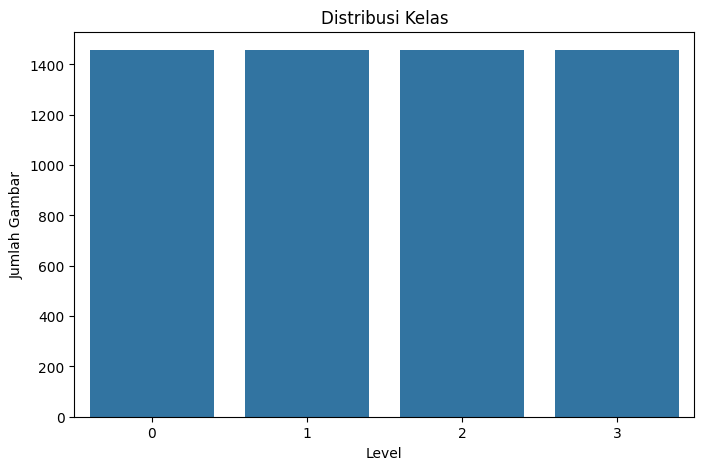

level
0    1457
1    1457
2    1457
3    1457
Name: count, dtype: int64

In [26]:
kelas = (
    df["level"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=kelas.index,
    y=kelas.values
)

plt.title("Distribusi Kelas")
plt.xlabel("Level")
plt.ylabel("Jumlah Gambar")

plt.show()

kelas

**7.2 Persentase Kelas**

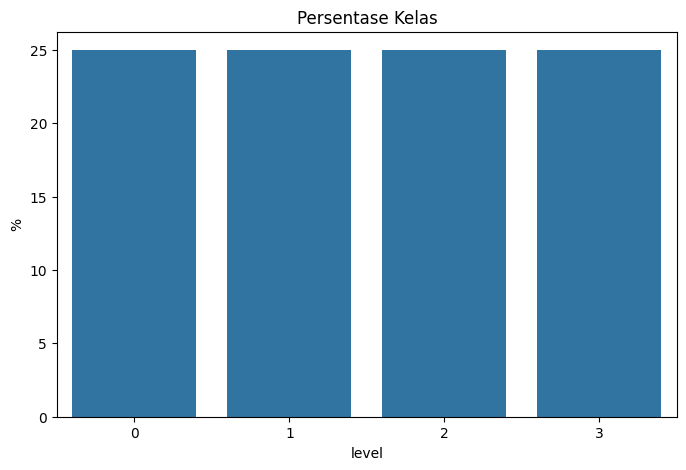

level
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

In [27]:
persen = (
    df["level"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

persen = persen.round(2)

plt.figure(figsize=(8,5))

sns.barplot(
    x=persen.index,
    y=persen.values
)

plt.title("Persentase Kelas")

plt.ylabel("%")

plt.show()

persen

**7.3 Distribusi Split Trainval dan Test**


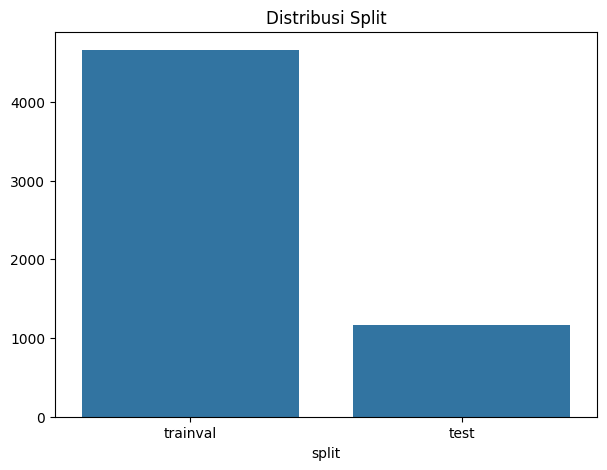

split
trainval    4660
test        1168
Name: count, dtype: int64

In [28]:
split = (
    df["split"]
    .value_counts()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=split.index,
    y=split.values
)

plt.title("Distribusi Split")

plt.show()

split

**7.4 Distribusi level pada data train dan data test**

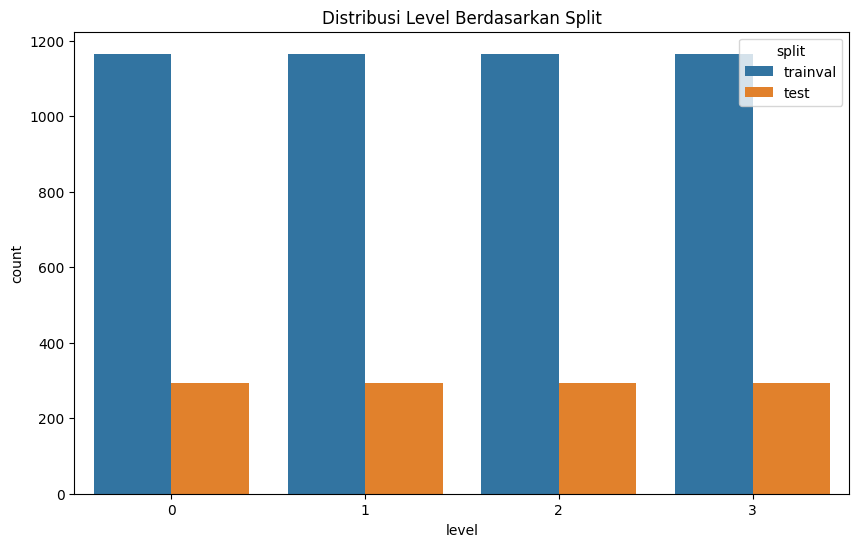

split,test,trainval
level,,
0,292,1165
1,292,1165
2,292,1165
3,292,1165


In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="level",
    hue="split"
)

plt.title(
    "Distribusi Level Berdasarkan Split"
)

plt.show()

pd.crosstab(
    df["level"],
    df["split"]
)

**7.5 Visualisasi Contoh Gambar per Level**


C:\Users\deaci\AppData\Local\Temp\ipykernel_35340\3848712532.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


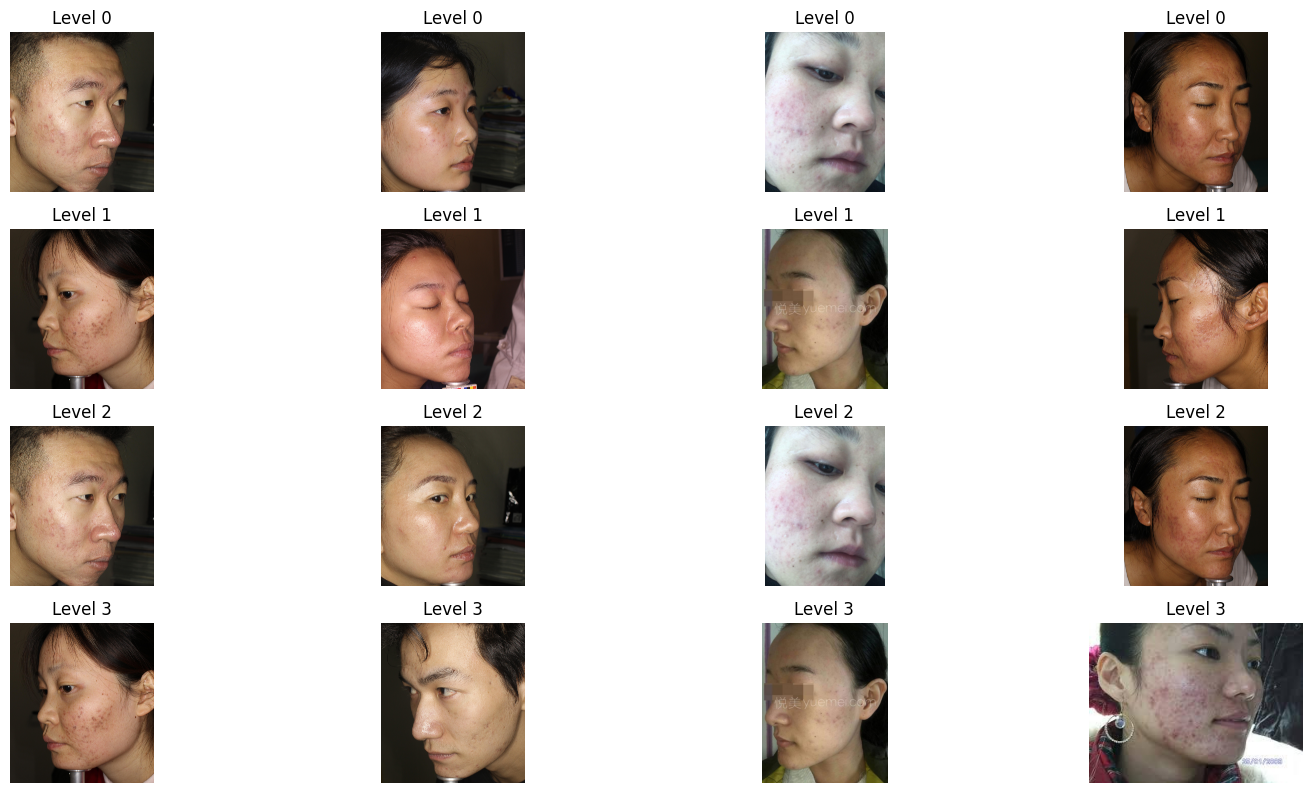

In [30]:
sample = (
    df
    .groupby("level")
    .apply(
        lambda x:
        x.sample(
            min(4,len(x)),
            random_state=42
        )
    )
)

plt.figure(
    figsize=(15,10)
)

for i,(_,row) in enumerate(sample.iterrows()):

    img = Image.open(
        row["filepath"]
    )

    plt.subplot(
        5,
        4,
        i+1
    )

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"Level {row['level']}"
    )

plt.tight_layout()

plt.show()

**7.6 Distribusi Ukuran Gambar**

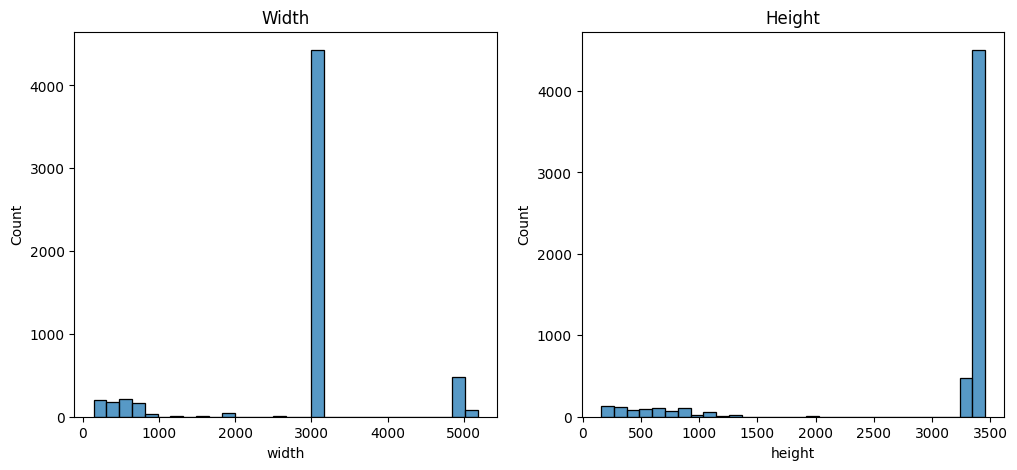

In [31]:
plt.figure(
    figsize=(12,5)
)

plt.subplot(1,2,1)

sns.histplot(
    df["width"],
    bins=30
)

plt.title("Width")

plt.subplot(1,2,2)

sns.histplot(
    df["height"],
    bins=30
)

plt.title("Height")

plt.show()

**7.7 Distribusi Aspect Rasio**

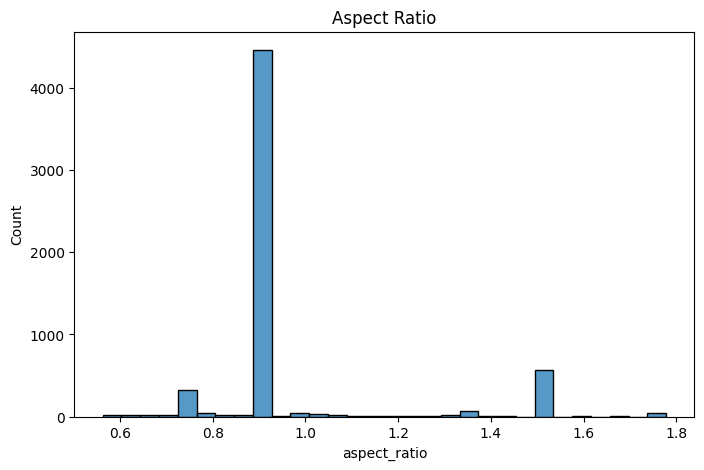

count    5828.000000
mean        0.966242
std         0.212263
min         0.562300
25%         0.900500
50%         0.900500
75%         0.900500
max         1.778400
Name: aspect_ratio, dtype: float64

In [32]:
plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["aspect_ratio"],
    bins=30
)

plt.title(
    "Aspect Ratio"
)

plt.show()

df["aspect_ratio"].describe()

**7.8 Brightness Per Level**


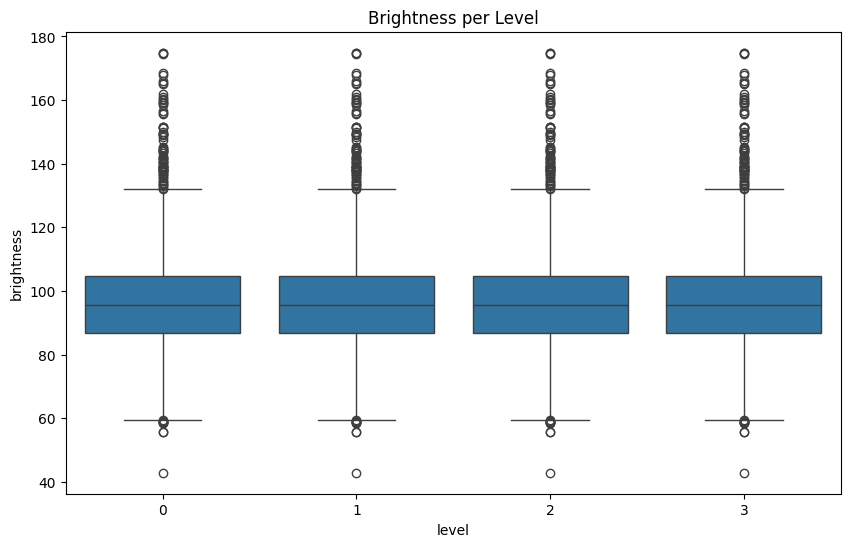

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
0,1457.0,97.547001,18.000054,42.91,86.71,95.56,104.85,174.88
1,1457.0,97.547001,18.000054,42.91,86.71,95.56,104.85,174.88
2,1457.0,97.547001,18.000054,42.91,86.71,95.56,104.85,174.88
3,1457.0,97.547001,18.000054,42.91,86.71,95.56,104.85,174.88


In [33]:
plt.figure(
    figsize=(10,6)
)

sns.boxplot(
    data=df,
    x="level",
    y="brightness"
)

plt.title(
    "Brightness per Level"
)

plt.show()

(
df
.groupby(
"level"
)
["brightness"]
.describe()
)

In [34]:
eda_summary = df[
[
"width",
"height",
"file_size_kb",
"aspect_ratio",
"total_pixels",
"brightness",
"blur_score"
]
].describe()

eda_summary

,width,height,file_size_kb,aspect_ratio,total_pixels,brightness,blur_score
count,5828.000000,5828.000000,5828.000000,5828.000000,5.828000e+03,5828.000000,5828.000000
mean,2918.286205,3027.748799,756.628085,0.966242,9.782844e+06,97.547001,109.039472
std,1112.585773,1002.478625,328.363424,0.212263,4.178080e+06,17.995419,206.416327
min,143.000000,155.000000,3.250000,0.562300,2.431000e+04,42.910000,3.940000
25%,3112.000000,3456.000000,679.990000,0.900500,1.075507e+07,86.710000,38.350000
50%,3112.000000,3456.000000,855.490000,0.900500,1.075507e+07,95.560000,74.950000
75%,3112.000000,3456.000000,962.800000,0.900500,1.075507e+07,104.850000,113.740000
max,5184.000000,3456.000000,1353.240000,1.778400,1.791590e+07,174.880000,3963.120000


# 8. Export Akhir

8.1 Penggabungan Level

lvel 4 disatukan dalam level 3 sebagai kelas tertinggi, dan tidak dihapus karena takutnya jumlah data berkurang. Model menjadi sederhana karena hanya membedakan 4 tingkat keparahan.

In [35]:

# Membuat folder output
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

# Export semua metadata
df.to_csv(
    f"{output_folder}/metadata_acne_final.csv",
    index=False
)

# Export metadata trainval
df[df["split"] == "trainval"].to_csv(
    f"{output_folder}/trainval_metadata.csv",
    index=False
)

# Export metadata test
df[df["split"] == "test"].to_csv(
    f"{output_folder}/test_metadata.csv",
    index=False
)

print("Export selesai.")
print("File berhasil dibuat:")
print("- metadata_acne_final.csv")
print("- trainval_metadata.csv")
print("- test_metadata.csv")

Export selesai.
File berhasil dibuat:
- metadata_acne_final.csv
- trainval_metadata.csv
- test_metadata.csv
